Completed 25/500
Completed 50/500
Completed 75/500
Completed 100/500
Completed 125/500
Completed 150/500
Completed 175/500
Completed 200/500
Completed 225/500
Completed 250/500
Completed 275/500
Completed 300/500
Completed 325/500
Completed 350/500
Completed 375/500
Completed 400/500
Completed 425/500
Completed 450/500
Completed 475/500
Completed 500/500
MDE ≈ 3.183% (alpha=0.05, target power=80.0%)


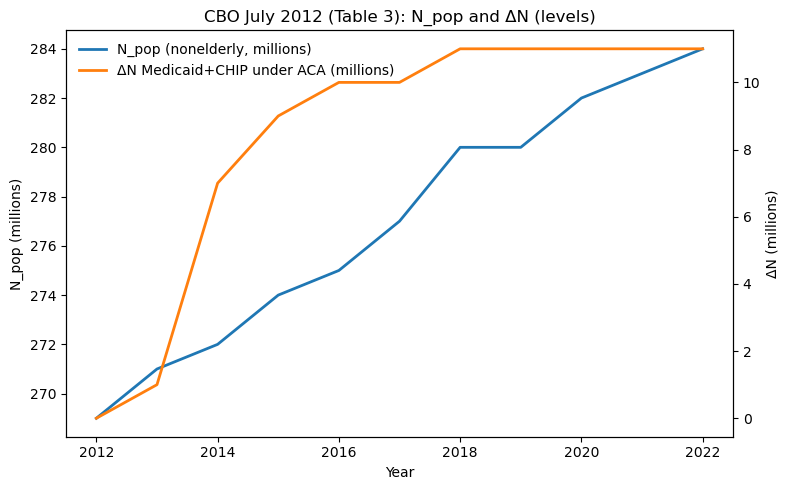

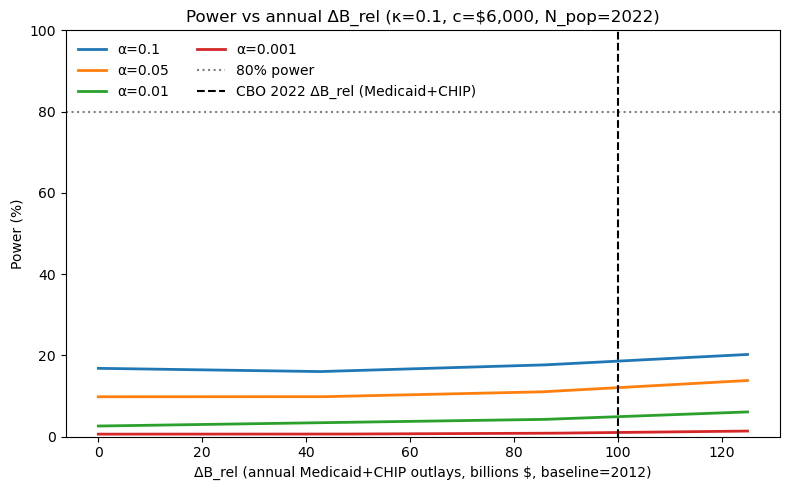

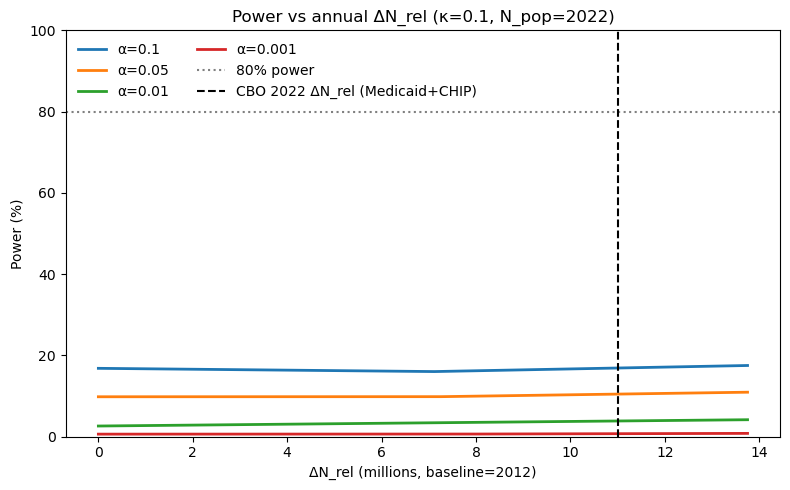

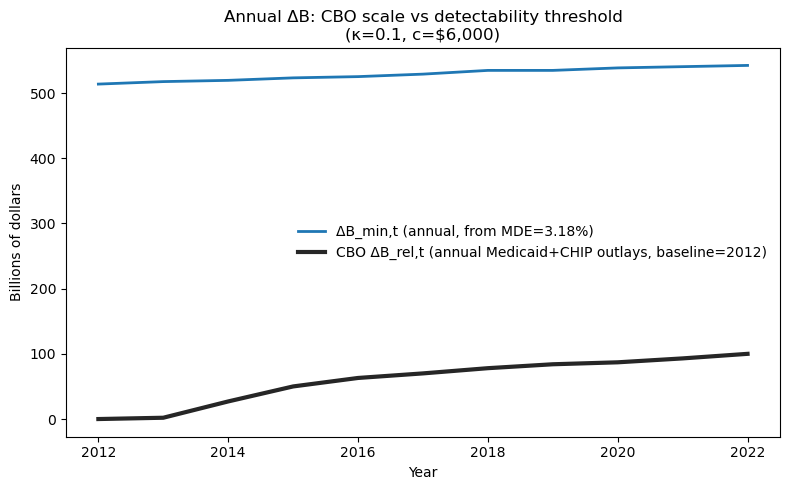

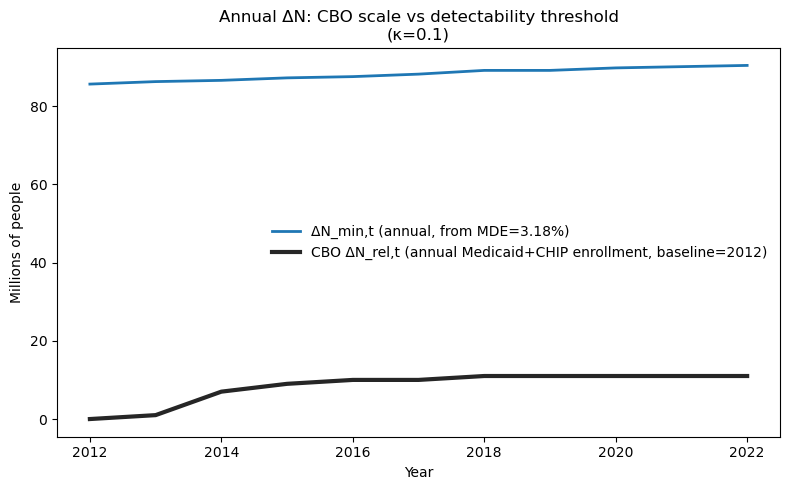

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

# =============================================================================
# A) POWER SIMULATION (same as your working code)
# =============================================================================

DATA_PATH = "Multiple Cause of Death, 1999-2020.csv"
N_SIM = 500
N_TREATED = 23

FIRST_YEAR, LAST_YEAR = 2006, 2011          # pre: 2006-2010, post: 2011-2013
EFFECT_GRID = np.arange(0, 0.05001, 0.0025) # 0% to 5% by 0.25%
ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05

rng = np.random.default_rng(1234)

# ----------------------------
# LOAD + CLEAN (CDC WONDER state×year)
# ----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df.dropna(subset=["deaths", "population"])

df = df[(df["year"] >= FIRST_YEAR) & (df["year"] < 2014)].copy()
df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)

# indices for fast group ops
state_codes = np.sort(df["state_id"].unique())
year_vals = np.sort(df["year"].unique())
state_to_idx = {s:i for i,s in enumerate(state_codes)}
year_to_idx  = {y:i for i,y in enumerate(year_vals)}

s = df["state_id"].map(state_to_idx).to_numpy()
tt = df["year"].map(year_to_idx).to_numpy()
S, T = len(state_codes), len(year_vals)

deaths0 = df["deaths"].to_numpy().astype(int)
pop = df["population"].to_numpy().astype(float)
w = pop
post = (df["year"].to_numpy() >= LAST_YEAR).astype(int)

# ----------------------------
# TWFE (1 regressor) with cluster-by-state variance
# ----------------------------
def twoway_demean(x):
    x_bar = (w * x).sum() / w.sum()
    xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
    xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
    return x - xs[s] - xt[tt] + x_bar

def twfe_beta_se(y, d):
    yt = twoway_demean(y)
    dt = twoway_demean(d)

    bread = np.sum(w * dt * dt)
    beta = np.sum(w * dt * yt) / bread

    u = yt - beta * dt
    score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
    var_beta = np.sum(score_g**2) / (bread**2)

    return beta, np.sqrt(var_beta), (S - 1)

# ----------------------------
# SIMULATE p-values for each effect size
# ----------------------------
J = len(EFFECT_GRID)
pvals = np.empty((N_SIM, J))
state_idx = np.arange(S)

for k in range(N_SIM):
    treated_states = rng.choice(state_idx, size=N_TREATED, replace=False)
    treated = np.isin(s, treated_states).astype(int)
    d = treated * post  # TreatPost regressor

    for j, eff in enumerate(EFFECT_GRID):
        removed = rng.binomial(n=deaths0, p=eff) * d
        deaths_eff = deaths0 - removed
        y = np.log((deaths_eff / pop) * 100000.0 + 1.0)

        beta, se_beta, df_t = twfe_beta_se(y, d)

        # nlcom 100*(exp(beta)-1)
        b_pct = 100.0 * (np.exp(beta) - 1.0)
        se_pct = 100.0 * np.exp(beta) * se_beta
        tstat = b_pct / se_pct
        pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)

    if (k + 1) % 25 == 0:
        print(f"Completed {k+1}/{N_SIM}")

# ----------------------------
# POWER TABLE
# ----------------------------
out = pd.DataFrame({"effect_size_pct": EFFECT_GRID * 100})
for a in ALPHAS:
    out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100

# ----------------------------
# MDE at (alpha, target power)
# ----------------------------
powcol = f"power_{ALPHA_FOR_MDE:.3f}"
gap = np.abs(out[powcol] - TARGET_POWER)
i1, i2 = np.argsort(gap.values)[:2]
x1, x2 = out.loc[[i1, i2], "effect_size_pct"].values
y1, y2 = out.loc[[i1, i2], powcol].values
m = (y2 - y1) / (x2 - x1)
b0 = y1 - m * x1
mde = (TARGET_POWER - b0) / m
print(f"MDE ≈ {mde:.3f}% (alpha={ALPHA_FOR_MDE}, target power={TARGET_POWER}%)")

# helper: interpolate power at any effect size
def power_at_effect(alpha, effect_pct):
    col = f"power_{alpha:.3f}"
    return float(np.interp(effect_pct, out["effect_size_pct"].values, out[col].values,
                           left=np.nan, right=np.nan))

# =============================================================================
# B) CBO JULY 2012 ANNUAL SERIES (levels + deltas relative to 2012)
# =============================================================================

years = np.arange(2012, 2023)

# July 2012 Table 3 (calendar years): TOTAL nonelderly pop (millions), ΔN Medicaid+CHIP under ACA (millions)
N_pop_m = np.array([269,271,272,274,275,277,280,280,282,283,284], dtype=float)
dN_m    = np.array([0,  1,  7,  9, 10, 10, 11, 11, 11, 11, 11], dtype=float)

# July 2012 Table 4 (fiscal years): ΔB Medicaid+CHIP outlays attributable to coverage provisions (billions)
dB_bil  = np.array([-1, 1, 26, 49, 62, 69, 77, 83, 86, 92, 99], dtype=float)

cbo = pd.DataFrame({
    "year": years,
    "N_pop": N_pop_m * 1e6,
    "dN": dN_m * 1e6,
    "dB": dB_bil * 1e9
})

# deltas relative to 2012
dN_2012 = cbo.loc[cbo.year == 2012, "dN"].iloc[0]
dB_2012 = cbo.loc[cbo.year == 2012, "dB"].iloc[0]
cbo["dN_rel"] = cbo["dN"] - dN_2012
cbo["dB_rel"] = cbo["dB"] - dB_2012

# =============================================================================
# C) BRIDGE SETTINGS FOR FIGURES
# =============================================================================

KAPPA_FIX = 0.10   # κ = r * τ
C_FIX = 6000.0     # $ per enrollee-year (stylized)

mde_share = mde / 100.0

# annual detectability thresholds
# |beta_pop| >= MDE and beta_pop = (ΔN/N_pop)*κ  =>  ΔN_min = N_pop*(MDE/κ)
cbo["dN_min"] = cbo["N_pop"] * (mde_share / KAPPA_FIX)

# map ΔN_min into ΔB_min using c (annual dollars)
cbo["dB_min"] = C_FIX * cbo["dN_min"]

# =============================================================================
# FIGURE 1: N_pop vs ΔN (levels)
# =============================================================================

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(cbo["year"], cbo["N_pop"]/1e6, lw=2, label="N_pop (nonelderly, millions)")
ax1.set_xlabel("Year")
ax1.set_ylabel("N_pop (millions)")

ax2 = ax1.twinx()
ax2.plot(cbo["year"], cbo["dN"]/1e6, lw=2, color="C1", label="ΔN Medicaid+CHIP under ACA (millions)")
ax2.set_ylabel("ΔN (millions)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper left")
plt.title("CBO July 2012 (Table 3): N_pop and ΔN (levels)")
plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 2: Power vs ΔB_rel (annual incremental outlays, baseline=2012)
# =============================================================================
# We convert ΔB -> implied effect via ΔN = ΔB / c, f = ΔN / N_pop_2022, beta = f*κ
N_pop_2022 = float(cbo.loc[cbo.year == 2022, "N_pop"].iloc[0])

def effect_pct_from_dB_rel(dB_rel):
    dN = dB_rel / C_FIX
    return 100.0 * (dN / N_pop_2022) * KAPPA_FIX

dB_grid = np.linspace(0, float(cbo["dB_rel"].max()*1.25), 200)  # annual ΔB_rel grid
plt.figure(figsize=(8,5))
for a in ALPHAS:
    pw = [power_at_effect(a, effect_pct_from_dB_rel(x)) for x in dB_grid]
    plt.plot(dB_grid/1e9, pw, lw=2, label=f"α={a:g}")

plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5, label=f"{TARGET_POWER:.0f}% power")
plt.axvline(float(cbo.loc[cbo.year==2022, "dB_rel"].iloc[0])/1e9, color="black", ls="--", lw=1.5,
            label="CBO 2022 ΔB_rel (Medicaid+CHIP)")
plt.ylim(0,100)
plt.xlabel("ΔB_rel (annual Medicaid+CHIP outlays, billions $, baseline=2012)")
plt.ylabel("Power (%)")
plt.title(f"Power vs annual ΔB_rel (κ={KAPPA_FIX}, c=${C_FIX:,.0f}, N_pop=2022)")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 3: Power vs ΔN_rel (annual incremental enrollment, baseline=2012)
# =============================================================================

def effect_pct_from_dN_rel(dN_rel):
    return 100.0 * (dN_rel / N_pop_2022) * KAPPA_FIX

dN_grid = np.linspace(0, float(cbo["dN_rel"].max()*1.25), 200)
plt.figure(figsize=(8,5))
for a in ALPHAS:
    pw = [power_at_effect(a, effect_pct_from_dN_rel(x)) for x in dN_grid]
    plt.plot(dN_grid/1e6, pw, lw=2, label=f"α={a:g}")

plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5, label=f"{TARGET_POWER:.0f}% power")
plt.axvline(float(cbo.loc[cbo.year==2022, "dN_rel"].iloc[0])/1e6, color="black", ls="--", lw=1.5,
            label="CBO 2022 ΔN_rel (Medicaid+CHIP)")
plt.ylim(0,100)
plt.xlabel("ΔN_rel (millions, baseline=2012)")
plt.ylabel("Power (%)")
plt.title(f"Power vs annual ΔN_rel (κ={KAPPA_FIX}, N_pop=2022)")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 4: Yearly ΔB_rel vs yearly ΔB_min (MDE threshold)
# =============================================================================

plt.figure(figsize=(8,5))
plt.plot(cbo["year"], cbo["dB_min"]/1e9, lw=2, label=f"ΔB_min,t (annual, from MDE={mde:.2f}%)")
plt.plot(cbo["year"], cbo["dB_rel"]/1e9, lw=3, color="black", alpha=0.85,
         label="CBO ΔB_rel,t (annual Medicaid+CHIP outlays, baseline=2012)")
plt.xlabel("Year")
plt.ylabel("Billions of dollars")
plt.title(f"Annual ΔB: CBO scale vs detectability threshold\n(κ={KAPPA_FIX}, c=${C_FIX:,.0f})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 5: Yearly ΔN_rel vs yearly ΔN_min (MDE threshold)
# =============================================================================

plt.figure(figsize=(8,5))
plt.plot(cbo["year"], cbo["dN_min"]/1e6, lw=2, label=f"ΔN_min,t (annual, from MDE={mde:.2f}%)")
plt.plot(cbo["year"], cbo["dN_rel"]/1e6, lw=3, color="black", alpha=0.85,
         label="CBO ΔN_rel,t (annual Medicaid+CHIP enrollment, baseline=2012)")
plt.xlabel("Year")
plt.ylabel("Millions of people")
plt.title(f"Annual ΔN: CBO scale vs detectability threshold\n(κ={KAPPA_FIX})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()